# 双均线（金叉 / 死叉）策略回测 · 交互式笔记本

本笔记对应量化课程作业，包含四部分内容：

1. **概念理解**：双均线策略、金叉、死叉；以及最大回撤（MDD）、夏普比率、累计回报等指标。
2. **Python 实现**：加载已存储数据 → 计算长短均线 → 计算买卖信号 → 可视化 → 模拟回测并计算指标。
3. **参数与标的探索**：调节均线周期、对比 **12 只基金 / 杰瑞股份**，观察收益变化；并做**止盈止损（TP/SL）网格扫描**。
4. **GitHub 可交互网页**：用 `ipywidgets` 做成交互面板（选标的 / 选回测区间 / 调佣金·滑点·止损·止盈），
   并通过 Voilà 部署到 GitHub Pages（见末尾说明）。

> 运行依赖（需与本笔记放在同一目录）：`dual_ma_lib.py`、`export_results.py`、数据 CSV（`fund_data/*.csv` 与 `杰瑞股份_日线_前复权.csv`）。
> 数据区间：**2023-01-01 起**（成立日晚的基金自动从成立日取）。成本模型按基金类型区分：
> ETF/LOF 用券商佣金（无印花税、100 份整手）；场外基金用申购费 + 赎回费分档（份额小数）；股票用佣金 + 印花税。

## 一、双均线策略与金叉 / 死叉

**均线（Moving Average, MA）**是把最近 N 个交易日的收盘价取平均，用来"抹平"短期波动、看清趋势方向。
短线均线（如 MA5）对价格反应快，长线均线（如 MA15/MA60）反应慢、更平滑。

**双均线策略**用两条均线判断趋势：

- **金叉（Golden Cross）**：短均线**由下向上**穿越长均线。代表短期动能转强、趋势可能转多，是**买入信号**。
- **死叉（Death Cross）**：短均线**由上向下**跌破长均线。代表短期动能转弱、趋势可能转空，是**卖出信号**。

> 注意：金叉/死叉是"穿越的那一瞬间"事件，不是"短均线在长均线上方"这个持续状态。
> 代码里用 `(前一日 diff ≤ 0) 且 (当日 diff > 0)` 来捕捉穿越瞬间，避免每天都误报信号。

## 二、量化策略效果的基础指标

- **累计回报（Cumulative Return）**：整个回测区间的总收益率 `(期末净值 / 初始资金 − 1)`，直观看"赚了多少"。
- **年化收益（Annualized Return）**：把区间收益换算成"按年计"的收益 `(1+总收益)^(252/交易日数) − 1`，便于不同长度区间横向比较。
- **最大回撤（Max Drawdown, MDD）**：账户净值从历史最高点回落到最低点的最大跌幅，
  `MDD = min(净值 / 历史峰值 − 1)`。它衡量"最惨会亏多少"，是风控核心指标。
- **夏普比率（Sharpe Ratio）**：`年化收益 / 年化波动`，表示"每承担一单位风险换来多少超额收益"。
  普通日频近似：`日收益均值 / 日收益标准差 × √252`。>1 通常算不错，>2 优秀，但要看样本长短。
- **胜率（Win Rate）**：盈利交易笔数 / 总交易笔数，反映信号"命中率"。
- **离场原因（exit_reason）**：本笔记额外记录每笔交易的离场方式——`cross`（死叉）/ `tp`（止盈）/ `sl`（止损）/ `end`（样本末强制平仓）。

本笔记还提供**买入持有（Buy & Hold）**作为对照基准——很多趋势策略在单边大牛市里反而跑不赢"一直拿着"。

## 三、加载数据、计算均线与交易信号

`SYMBOLS` 已接入 **12 只基金 + 杰瑞股份**。每只基金标注了成本模型（`etf` / `otc` / `stock`）、
整手（`lot`）与是否份额小数（`fractional`），回测时自动套用对应费用与仓位规则。

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import dual_ma_lib as lib
import os

print("依赖加载完成 ✅")

依赖加载完成 ✅


In [2]:
# 标的字典：显示名 -> {路径, 成本模型, 整手, 份额小数}
SYMBOLS = {
    "中证A500 (022430.OF)":        {"path": "fund_data/022430_中证A500.csv",        "cost_model": "otc",  "lot": 1,   "fractional": True},
    "中证1000指数增强 (017953.OF)": {"path": "fund_data/017953_中证1000指数增强.csv", "cost_model": "otc",  "lot": 1,   "fractional": True},
    "半导体芯片 (012970.OF)":       {"path": "fund_data/012970_半导体芯片.csv",       "cost_model": "otc",  "lot": 1,   "fractional": True},
    "有色金属 (004432.OF)":         {"path": "fund_data/004432_有色金属.csv",         "cost_model": "otc",  "lot": 1,   "fractional": True},
    "黄金产业股票 (021958.OF)":     {"path": "fund_data/021958_黄金产业股票.csv",     "cost_model": "otc",  "lot": 1,   "fractional": True},
    "黄金基金 (018392.OF)":         {"path": "fund_data/018392_黄金基金.csv",         "cost_model": "otc",  "lot": 1,   "fractional": True},
    "乐享生活 (004320.OF)":         {"path": "fund_data/004320_乐享生活.csv",         "cost_model": "otc",  "lot": 1,   "fractional": True},
    "白酒基金LOF (161725.SZ)":      {"path": "fund_data/161725_白酒基金LOF.csv",      "cost_model": "etf",  "lot": 100, "fractional": False},
    "养殖ETF (159865.SZ)":          {"path": "fund_data/159865_养殖ETF.csv",          "cost_model": "etf",  "lot": 100, "fractional": False},
    "军工ETF (512660.SH)":          {"path": "fund_data/512660_军工ETF.csv",          "cost_model": "etf",  "lot": 100, "fractional": False},
    "科创芯片ETF (588200.SH)":      {"path": "fund_data/588200_科创芯片ETF.csv",      "cost_model": "etf",  "lot": 100, "fractional": False},
    "中概互联ETF (513050.SH)":      {"path": "fund_data/513050_中概互联ETF.csv",      "cost_model": "etf",  "lot": 100, "fractional": False},
    "杰瑞股份 (002353.SZ)":         {"path": "杰瑞股份_日线_前复权.csv",              "cost_model": "stock","lot": 100, "fractional": False},
}

DEFAULT_SYMBOL = "科创芯片ETF (588200.SH)"

def load_symbol(name):
    return lib.load_price_csv(SYMBOLS[name]["path"])

df = load_symbol(DEFAULT_SYMBOL)
cfg = SYMBOLS[DEFAULT_SYMBOL]
print(f"已加载 [{DEFAULT_SYMBOL}]：{len(df)} 行，{df['date'].iloc[0]} ~ {df['date'].iloc[-1]}  | 成本模型={cfg['cost_model']}")
df.head()

已加载 [科创芯片ETF (588200.SH)]：851 行，2023-01-03 ~ 2026-07-10  | 成本模型=etf


,date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,2023-01-03,1.022,1.050,1.016,1.050,1.028,0.022,2.1401,286812.0,29693.602
1,2023-01-04,1.051,1.062,1.035,1.043,1.050,-0.007,-0.6667,266138.0,27773.251
2,2023-01-05,1.047,1.058,1.036,1.057,1.043,0.014,1.3423,312809.0,32802.319
3,2023-01-06,1.054,1.064,1.043,1.051,1.057,-0.006,-0.5676,381000.0,40102.402
4,2023-01-09,1.051,1.071,1.046,1.056,1.051,0.005,0.4757,349712.0,36946.235


In [3]:
# 1) 计算短 / 长均线；2) 用"穿越瞬间"判定金叉 / 死叉
short, long = 5, 15
df_ma = lib.compute_mas(df, short, long)
df_sig = lib.compute_cross_signals(df_ma)

n_gold = int(df_sig["golden_cross"].sum())
n_death = int(df_sig["death_cross"].sum())
print(f"短均线 MA{short}，长均线 MA{long}")
print(f"样本内金叉次数：{n_gold}，死叉次数：{n_death}")
df_ma[["date", "close", "ma_s", "ma_l"]].tail()

短均线 MA5，长均线 MA15
样本内金叉次数：31，死叉次数：31


,date,close,ma_s,ma_l
846,2026-07-06,4.402,4.5880,4.333800
847,2026-07-07,4.432,4.4872,4.382067
848,2026-07-08,4.484,4.4214,4.431533
849,2026-07-09,4.897,4.5176,4.494733
850,2026-07-10,4.565,4.5560,4.524000


### 3.4 可视化：价格、长短均线、买卖信号

下面运行回测（信号次日开盘价成交，防前视；止盈止损在触发次日开盘价执行），并在图上用 ▲ 标记买入、▼ 标记卖出。

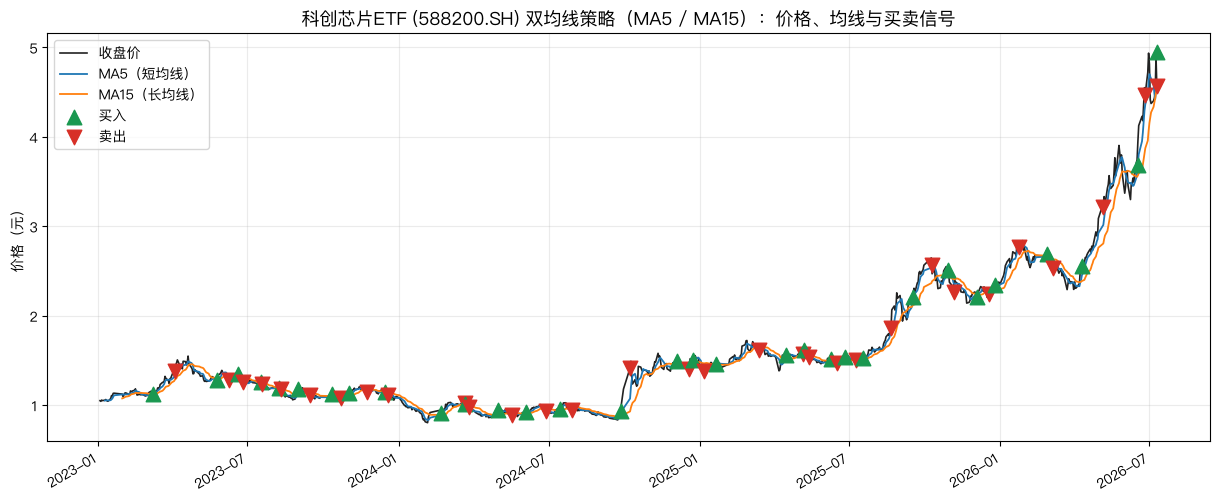

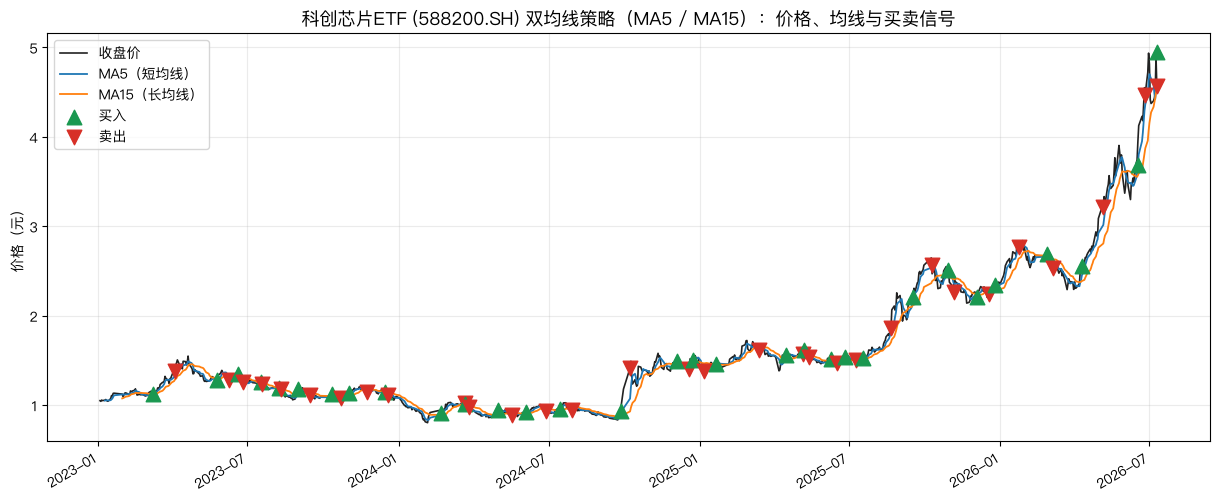

In [4]:
equity_curve, trade_history, meta = lib.run_backtest(
    df, short=short, long=long, symbol_name=DEFAULT_SYMBOL,
    cost_model=cfg["cost_model"], lot=cfg["lot"], fractional=cfg["fractional"],
    stop_loss=0.10, take_profit=0.20)
lib.plot_price_signals(df_ma, short, long, trade_history, symbol_name=DEFAULT_SYMBOL)

## 四、模拟交易与回测，计算量化指标

回测约定（防前视、成本敏感）：

- **成交时点**：信号在 bar *i* 出现，在 bar *i+1* 的**开盘价**成交（避免"用收盘价作弊"的前视偏差）。
- **止盈 / 止损**：在 bar *i* 根据当日 high/low/close 检测触发，于 bar *i+1* 开盘价执行（同样防前视）。
- **T+1**：当天买入，最早次日才能卖出；场外基金 T 日申赎 T+1 确认净值。
- **整手 / 仓位**：ETF/股票 100 份（股）整手；场外基金份额可为小数（按金额申购）。
- **费用（按基金类型，行业默认）**：
  - 股票：佣金万 2.5 双边（最低 5 元）+ 印花税千 1（仅卖）。
  - ETF/LOF：券商佣金万 0.5（无最低、无印花税），100 份整手。
  - 场外基金：申购费 0.1% + 赎回费分档（持有 <7 天 1.5% / 7 天~1 年 0.5% / ≥1 年 0）。
- **预热（warmup）**：均线前若干根为 NaN，预热段只更新状态、不交易；指标就绪后从评估起点开始统计。
- **末尾强制平仓**：样本结束仍有持仓则按最后收盘价平仓并计入成交，标注 `exit_reason="end"`。

In [5]:
from export_results import export_results

equity_curve, trade_history, meta = lib.run_backtest(
    df, short=short, long=long, initial_cash=100_000.0,
    buy_comm=0.0005, slippage=0.0,
    cost_model=cfg["cost_model"], lot=cfg["lot"], fractional=cfg["fractional"],
    stop_loss=0.10, take_profit=0.20,
    symbol=DEFAULT_SYMBOL, symbol_name=DEFAULT_SYMBOL)

paths = export_results(
    equity_curve, trade_history, "dual_ma_588200",
    initial_cash=meta["initial_cash"], start=meta["eval_start"], end=meta["eval_end"],
    market="china_a", strategy_name="双均线", symbol=DEFAULT_SYMBOL,
    is_flat_at_end=meta["is_flat_at_end"])

metrics = lib.compute_metrics(equity_curve, trade_history)

# 买入持有基准（同区间、同等费用模型）
s_idx = df.index[df["date"] == meta["eval_start"]][0]
e_idx = df.index[df["date"] == meta["eval_end"]][0]
bh_eq = lib.buy_and_hold(df, initial_cash=100_000.0, start_idx=s_idx, end_idx=e_idx,
                         cost_model=cfg["cost_model"], lot=cfg["lot"], fractional=cfg["fractional"])
bh_ret = (bh_eq[-1]["value"] / bh_eq[0]["value"] - 1) * 100

print("评估区间：", meta["eval_start"], "~", meta["eval_end"], "| 成本模型:", meta["cost_model"])
print(f"策略累计收益 % : {metrics['total_return_pct']}  |  买入持有 % : {round(bh_ret, 2)}")
print(f"夏普        : {metrics['sharpe']}")
print(f"最大回撤 %  : {metrics['max_drawdown_pct']}")
print(f"胜率 %      : {metrics['win_rate_pct']}  |  交易笔数 : {metrics['total_trades']}")
print(f"离场原因    : {metrics.get('exit_reasons')}")

# 成交明细
pd.DataFrame(trade_history)[["entry_date", "exit_date", "size",
                             "entry_price", "exit_price", "pnl_pct", "holding_bars", "exit_reason"]]

评估区间： 2023-01-31 ~ 2026-07-10 | 成本模型: etf
策略累计收益 % : 163.01  |  买入持有 % : 316.78
夏普        : 1.22
最大回撤 %  : 25.35
胜率 %      : 45.16  |  交易笔数 : 31
离场原因    : {'tp': 7, 'cross': 23, 'end': 1}


,entry_date,exit_date,size,entry_price,exit_price,pnl_pct,holding_bars,exit_reason
0,2023-03-08,2023-04-04,88900,1.124,1.385,23.13,19,tp
1,2023-05-25,2023-06-09,96100,1.280,1.286,0.39,11,cross
2,2023-06-20,2023-06-26,91900,1.344,1.257,-6.54,2,cross
3,2023-07-17,2023-07-19,91700,1.258,1.237,-1.74,2,cross
4,2023-08-09,2023-08-11,95400,1.188,1.178,-0.92,2,cross
5,2023-09-01,2023-09-15,95200,1.180,1.111,-5.92,10,cross
6,2023-10-12,2023-10-23,94200,1.122,1.083,-3.55,7,cross
7,2023-11-01,2023-11-23,89800,1.135,1.146,0.89,16,cross
8,2023-12-15,2023-12-19,89500,1.149,1.113,-3.21,2,cross
9,2024-02-21,2024-03-21,108700,0.916,1.020,11.27,21,cross


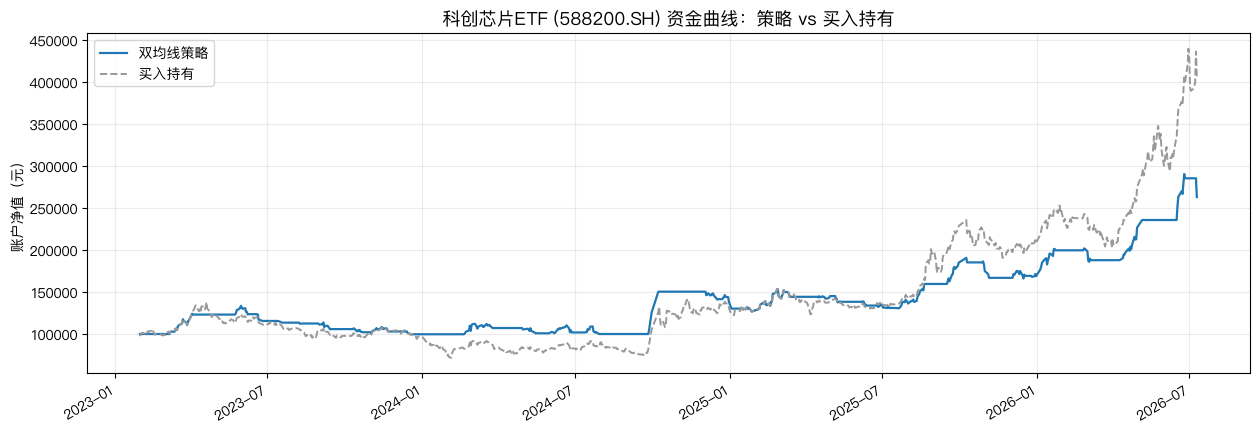

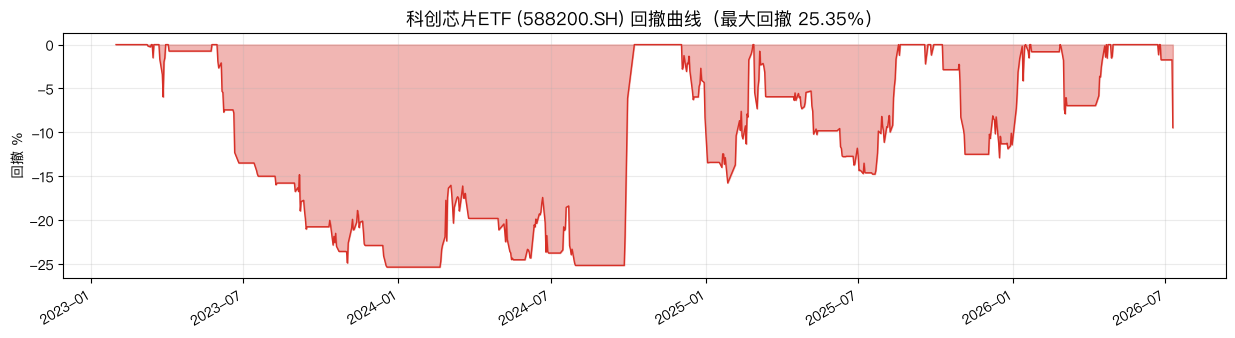

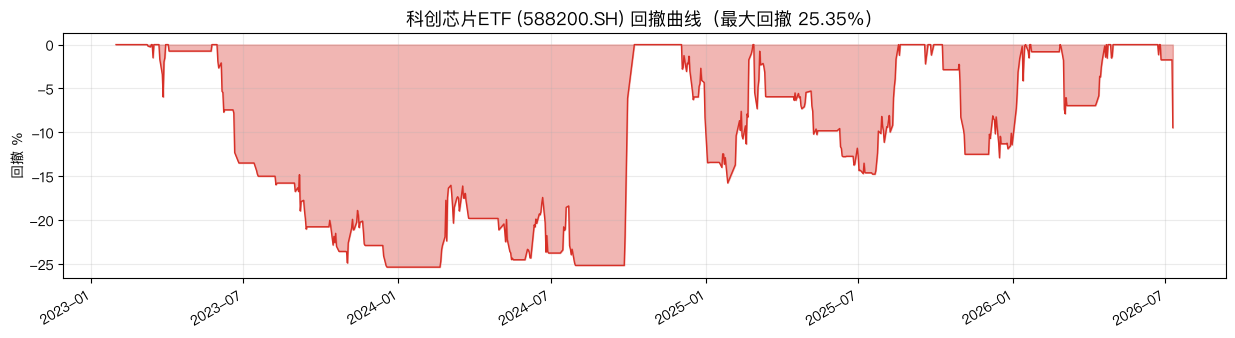

In [6]:
lib.plot_equity(equity_curve, bh_eq, symbol_name=DEFAULT_SYMBOL)
lib.plot_drawdown(equity_curve, symbol_name=DEFAULT_SYMBOL)

## 五、交互式回测面板（用于 GitHub 网页）

拖动下方控件即可实时重跑回测：换基金、改均线周期、选回测起止日期、调佣金(申购费) / 滑点 / 止损 / 止盈。
代码会自动画出价格信号图、资金曲线、回撤图并打印指标与离场原因。

> 说明：GitHub 上要让控件"可点可拖"，需用 **Voilà** 渲染（见第八节），普通 `.ipynb` 静态预览是只读的。
> 下拉框里已包含 12 只基金与杰瑞股份，任选即可。

In [7]:
def run_panel(symbol, short, long, start, end, buy_comm, slippage, stop_loss, take_profit):
    if short >= long:
        print("⚠️ 短均线必须小于长均线"); return
    cfg = SYMBOLS[symbol]
    dfx = lib.load_price_csv(cfg["path"])
    start_s = str(start)[:10] if start else None
    end_s = str(end)[:10] if end else None
    eq, tr, m = lib.run_backtest(
        dfx, short=int(short), long=int(long), initial_cash=100_000.0,
        buy_comm=float(buy_comm),
        sell_tax=0.001 if cfg["cost_model"] == "stock" else 0.0,
        slippage=float(slippage),
        cost_model=cfg["cost_model"], lot=cfg["lot"], fractional=cfg["fractional"],
        stop_loss=(float(stop_loss) if float(stop_loss) > 0 else None),
        take_profit=(float(take_profit) if float(take_profit) > 0 else None),
        symbol_name=symbol, start_date=start_s, end_date=end_s)
    if not eq:
        print("⚠️ 区间过短或无有效信号"); return
    dfm = lib.compute_mas(dfx, int(short), int(long))
    lib.plot_price_signals(dfm, int(short), int(long), tr, symbol_name=symbol)
    s_idx = dfx.index[dfx["date"] == m["eval_start"]][0]
    e_idx = dfx.index[dfx["date"] == m["eval_end"]][0]
    lib.plot_equity(eq, lib.buy_and_hold(dfx, start_idx=s_idx, end_idx=e_idx,
                         cost_model=cfg["cost_model"], lot=cfg["lot"], fractional=cfg["fractional"]),
                    symbol_name=symbol)
    lib.plot_drawdown(eq, symbol_name=symbol)
    met = lib.compute_metrics(eq, tr)
    print(f"[{symbol}] 成本模型={cfg['cost_model']} | MA{int(short)}/MA{int(long)} | 评估 {m['eval_start']}~{m['eval_end']}")
    print(f"累计收益% {met['total_return_pct']} | 夏普 {met['sharpe']} | "
          f"最大回撤% {met['max_drawdown_pct']} | 胜率% {met['win_rate_pct']} | 笔数 {met['total_trades']}")
    print(f"离场原因 {met.get('exit_reasons')}")

symbol_w = widgets.Dropdown(options=list(SYMBOLS.keys()), value=DEFAULT_SYMBOL, description="标的")
short_w  = widgets.IntSlider(min=3, max=60, step=1, value=5, description="短均线")
long_w   = widgets.IntSlider(min=5, max=120, step=1, value=15, description="长均线")
start_w  = widgets.DatePicker(value=pd.Timestamp("2023-01-01").date(), description="开始日期")
end_w    = widgets.DatePicker(value=pd.Timestamp("2026-07-10").date(), description="结束日期")
comm_w   = widgets.FloatSlider(min=0, max=0.002, step=0.00005, value=0.0005, description="佣金/申购费")
slip_w   = widgets.FloatSlider(min=0, max=0.01, step=0.0005, value=0.0, description="滑点")
sl_w     = widgets.FloatSlider(min=0, max=0.3, step=0.01, value=0.10, description="止损(0=无)")
tp_w     = widgets.FloatSlider(min=0, max=0.5, step=0.01, value=0.20, description="止盈(0=无)")

ui = widgets.VBox([
    widgets.HBox([symbol_w, short_w, long_w]),
    widgets.HBox([start_w, end_w]),
    widgets.HBox([comm_w, slip_w, sl_w, tp_w]),
])
out = widgets.interactive_output(run_panel, {
    "symbol": symbol_w, "short": short_w, "long": long_w,
    "start": start_w, "end": end_w,
    "buy_comm": comm_w, "slippage": slip_w,
    "stop_loss": sl_w, "take_profit": tp_w,
})
display(ui, out)

Output()

## 六、不同参数 / 标的的收益观察（参数扫描）

下面在 (短均线 × 长均线) 网格上跑一遍，输出明细表与累计收益热力图，便于观察参数敏感性。
你也把 `symbol` 换成 `SYMBOLS` 里的其它标的（基金）来对比。

,短均线,长均线,累计收益%,sharpe,最大回撤%,交易笔数
0,3,10,119.98,0.985,26.35,45
1,3,15,174.60,1.291,21.87,32
2,3,20,176.90,1.291,31.35,30
3,3,30,111.08,1.042,30.15,27
4,3,40,65.69,0.813,28.08,20
5,3,60,3.64,0.155,43.54,18
6,5,10,151.44,1.171,22.90,39
7,5,15,165.10,1.229,25.22,31
8,5,20,197.73,1.445,27.68,25
9,5,30,121.37,1.109,30.11,23


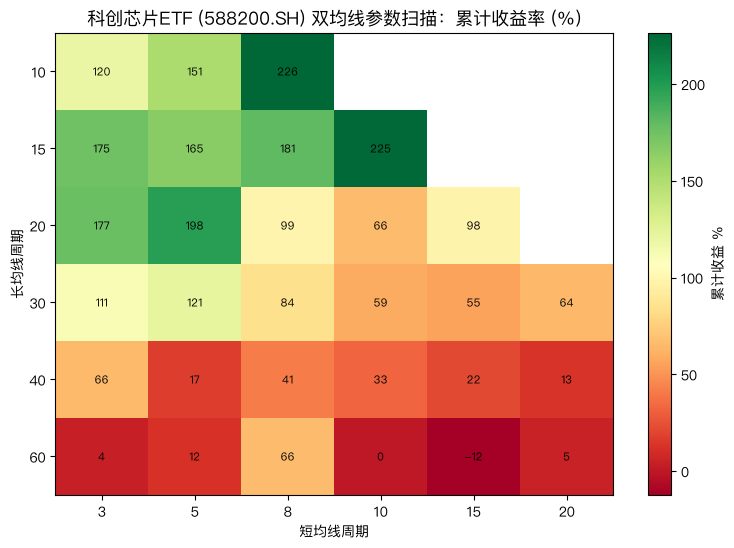

,short,long,total_return_pct,sharpe,max_drawdown_pct,total_trades
0,3,10,119.98,0.985,26.35,45
1,3,15,174.60,1.291,21.87,32
2,3,20,176.90,1.291,31.35,30
3,3,30,111.08,1.042,30.15,27
4,3,40,65.69,0.813,28.08,20
5,3,60,3.64,0.155,43.54,18
6,5,10,151.44,1.171,22.90,39
7,5,15,165.10,1.229,25.22,31
8,5,20,197.73,1.445,27.68,25
9,5,30,121.37,1.109,30.11,23


In [8]:
def sweep(symbol, shorts=(3, 5, 8, 10, 15, 20), longs=(10, 15, 20, 30, 40, 60)):
    cfg = SYMBOLS[symbol]
    dfx = lib.load_price_csv(cfg["path"])
    rows = []
    for sh in shorts:
        for lo in longs:
            if sh >= lo:
                continue
            eq, tr, _ = lib.run_backtest(dfx, short=sh, long=lo, symbol_name=symbol,
                                         cost_model=cfg["cost_model"], lot=cfg["lot"],
                                         fractional=cfg["fractional"], stop_loss=0.10, take_profit=0.20)
            m = lib.compute_metrics(eq, tr)
            rows.append({"short": sh, "long": lo, "total_return_pct": m["total_return_pct"],
                         "sharpe": m["sharpe"], "max_drawdown_pct": m["max_drawdown_pct"],
                         "total_trades": m["total_trades"]})
    g = pd.DataFrame(rows)
    display(g.rename(columns={"short": "短均线", "long": "长均线",
                              "total_return_pct": "累计收益%", "max_drawdown_pct": "最大回撤%",
                              "total_trades": "交易笔数"}))
    lib.plot_sweep_heatmap(g, symbol_name=symbol)
    return g

sweep(DEFAULT_SYMBOL)

## 七、止盈 / 止损（TP/SL）网格扫描

双均线本身是"无风控"的趋势跟踪，遇到单边反转会吐回利润。下面在 (止损 × 止盈) 网格上扫描，
观察不同风控档位对累计收益、夏普、最大回撤的影响——这正是作业要求的"止盈止损网格分布"。

- 行 = 止损比例，列 = 止盈比例；颜色 = 对应指标（累计收益 / 夏普）。
- 可在下方 `tp_sl_grid_run` 里换标的、换均线周期。

,止损,止盈,累计收益%,夏普,最大回撤%,胜率%,交易笔数
0,0.05,0.10,77.83,0.854,24.62,45.16,31
1,0.05,0.15,109.93,1.017,24.61,45.16,31
2,0.05,0.20,179.20,1.292,24.61,45.16,31
3,0.05,0.30,232.26,1.405,24.62,45.16,31
4,0.08,0.10,73.45,0.819,25.36,45.16,31
5,0.08,0.15,104.77,0.984,25.35,45.16,31
6,0.08,0.20,172.45,1.261,25.35,45.16,31
7,0.08,0.30,224.29,1.376,25.36,45.16,31
8,0.10,0.10,67.50,0.773,25.36,45.16,31
9,0.10,0.15,97.71,0.941,25.35,45.16,31


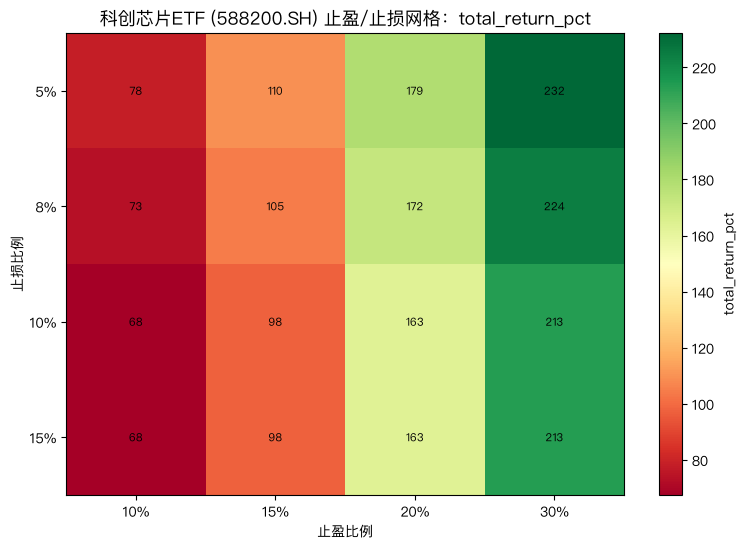

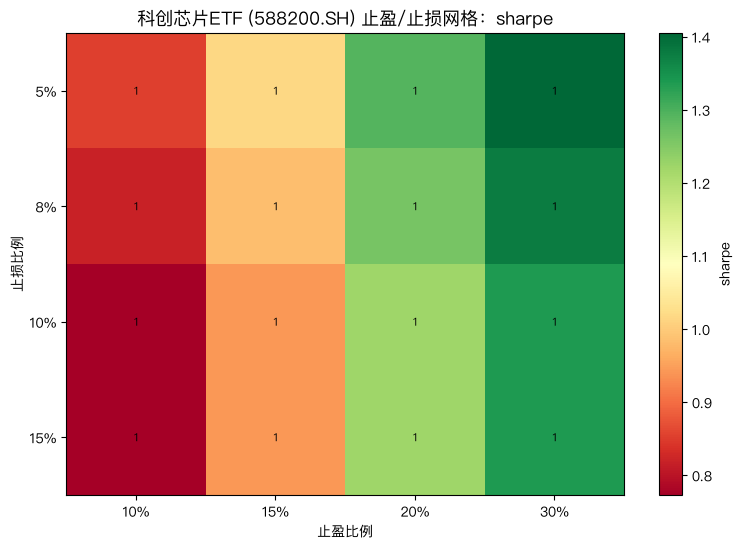

,stop_loss,take_profit,total_return_pct,sharpe,max_drawdown_pct,win_rate_pct,total_trades
0,0.05,0.10,77.83,0.854,24.62,45.16,31
1,0.05,0.15,109.93,1.017,24.61,45.16,31
2,0.05,0.20,179.20,1.292,24.61,45.16,31
3,0.05,0.30,232.26,1.405,24.62,45.16,31
4,0.08,0.10,73.45,0.819,25.36,45.16,31
5,0.08,0.15,104.77,0.984,25.35,45.16,31
6,0.08,0.20,172.45,1.261,25.35,45.16,31
7,0.08,0.30,224.29,1.376,25.36,45.16,31
8,0.10,0.10,67.50,0.773,25.36,45.16,31
9,0.10,0.15,97.71,0.941,25.35,45.16,31


In [9]:
def tp_sl_grid_run(symbol, short=5, long=15,
                     sl_list=(0.05, 0.08, 0.10, 0.15),
                     tp_list=(0.10, 0.15, 0.20, 0.30)):
    cfg = SYMBOLS[symbol]
    dfx = lib.load_price_csv(cfg["path"])
    g = lib.tp_sl_grid(dfx, short, long, list(sl_list), list(tp_list),
                       cost_model=cfg["cost_model"], lot=cfg["lot"], fractional=cfg["fractional"],
                       buy_comm=0.0005, slippage=0.0)
    display(g.rename(columns={
        "stop_loss": "止损", "take_profit": "止盈", "total_return_pct": "累计收益%",
        "sharpe": "夏普", "max_drawdown_pct": "最大回撤%", "win_rate_pct": "胜率%",
        "total_trades": "交易笔数"}))
    lib.plot_tp_sl_heatmap(g, value_col="total_return_pct", symbol_name=symbol)
    lib.plot_tp_sl_heatmap(g, value_col="sharpe", symbol_name=symbol)
    return g

tp_sl_grid_run(DEFAULT_SYMBOL)

## 八、总结：双均线策略的适用场景与应用心得

结合上面 12 只基金（2023 起）的结果，可得几点体会：

1. **趋势市有效、震荡市吃亏**。双均线是趋势跟踪策略：单边上涨/下跌时能吃到大段利润；
   但横盘来回穿越会频繁金叉死叉，反复"高买低卖"被手续费和滑点吃掉收益（即"洗刷成本"）。
2. **强牛市里常跑不赢买入持有**。在 588200 这类单边牛基上，策略常因"等金叉确认才进场"而错过早期启动段。
3. **参数敏感、易过拟合**。扫描显示不同 (短,长) 组合收益差异很大；样本需更长 + 样本外验证，不能直接挑最好看的参数。
4. **止盈止损能压回撤，但也会截断趋势利润**。TP/SL 网格显示：收紧止损会降低最大回撤，却可能牺牲累计收益；
   止盈设太矮会把大牛腿砍断。没有"万能档位"，要配合标的波动特性。
5. **成本与滑点很关键**。佣金、印花税/赎回费、滑点会显著侵蚀短线频繁交易的成绩；面板里把滑点调高，很多参数立刻变脸。
6. **适用场景**：中长线趋势明确的指数/ETF/行业基金；不适合分钟级或高换手。可作为仓位"开关"（持有/空仓）的辅助。

> 本笔记样本仅约 2~3 年、单只标的，结论仅供参考，不构成投资建议。

## 九、部署到 GitHub Pages（可交互网页）

要让上面的 `ipywidgets` 控件在 GitHub 上"可点可拖"，用 **Voilà** 把笔记本渲染成网页，
再用 GitHub Actions 自动发布到 GitHub Pages。仓库里需要包含：`双均线策略回测.ipynb`、
`dual_ma_lib.py`、`export_results.py`、`fetch_fund_data.py`、以及所有数据 CSV（`fund_data/*.csv`、`杰瑞股份_日线_前复权.csv`）。

本目录已附带 `.github/workflows/deploy.yml`。用法：

1. 把上述文件推送到仓库的 `main` 分支（数据 CSV 也一起提交，控件才能读到基金）。
2. 在仓库 **Settings → Pages → Build and deployment → Source** 选择 **GitHub Actions**。
3. 推送后 Actions 会自动构建并把网页发布到 `https://<用户名>.github.io/<仓库名>/`。

> 静态 `.ipynb` 预览（如 GitHub 直接打开、nbviewer）是只读的，控件不会动；
> 只有 Voilà 渲染的页面才真正可交互。